# Forecasting climate data using Physics Informed Long Short-Term Memory networks (PI-LSTM)

This code implements the PINT LSTM ([Code](https://github.com/KV-Park/PINT/blob/main/PINT%5BTraining%5D.ipynb) | [Paper](https://arxiv.org/pdf/2502.04018)) to forecast on the Kaggle "Daily Climate time series data" dataset.

Dataset:
- Download dataset from [here](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data) and store in data/ folder in this repository

In [54]:
import os
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.dates import MonthLocator, DayLocator, DateFormatter
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler

from helper_functions import create_sequences, forecast_with_model, set_seed, train_models, plot_loss
from models import GRU, LSTM, RNN, PhysicsInformedGRU, PhysicsInformedLSTM, PhysicsInformedRNN

ImportError: cannot import name 'PhysicsInformedGRU' from 'models' (/Users/zz25874/Documents/foundation_year/foundations/TB2_essay_PIML/implementation/PIML-foundations-tb2/models.py)

In [2]:
matplotlib.rcParams.update({'font.size': 16})

In [3]:
# Key parameters:
SEED_VALUE = 2026

# Preprocessing
# Experiment 1: Matching PINT set up
# SEQ_LENGTH = 90  # Number of past time steps to look at 
# PRED_LENGTH = 30  # Number of time steps to predict

# Experiment 2:
SEQ_LENGTH = 20  # Number of past time steps to look at 
PRED_LENGTH = 1  # Number of time steps to predict

# Model set up
input_size=1
output_size = PRED_LENGTH
hidden_size=64
num_layers=1
dropout=0
NUM_EPOCHS=50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
set_seed(SEED_VALUE)

In [5]:
# Initialise models
# Experiment 1
# models = {
#     "LSTM": LSTM(input_size, hidden_size, num_layers, output_size),
#     "PI-LSTM": PhysicsInformedLSTM(input_size, hidden_size, num_layers, output_size)
# }

# Experiment 2
models = {
    "RNN": RNN(input_size, hidden_size, num_layers, output_size),
    "LSTM": LSTM(input_size, hidden_size, num_layers, output_size),
    "GRU": GRU(input_size, hidden_size, num_layers, output_size)
}

/Users/zz25874/Documents/foundation_year/foundations/TB2_essay_PIML/implementation/PIML-foundations-tb2/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


## Import data

In [6]:
files = ["DailyDelhiClimateTrain.csv", "DailyDelhiClimateTest.csv"]

data = []
for file in files:
    df = pd.read_csv(os.path.join("data/", file))
    df["datetimes"] = [datetime.strptime(d,'%Y-%m-%d').date() for d in df["date"].values]
    if "Train" in file:
        # print("End of \"Train\" data before:\n", df.tail())  # Shows 2017-01-01 at end
        df = df[:-1]  # Remove last row of training data because of duplcate in test
        # print("End of \"Train\" data after dropping last row:\n", df.tail())  # Shows 2017-01-01 at end
    # else:
        # print("Start of \"Test\" data:\n", df.head())  # Shows 2017-01-01 at start
    data.append(df)

all_data_df = pd.concat(data, ignore_index=True)

In [7]:
len(all_data_df)

1575

## Pre-process data

In [8]:
# split training:val:test as 70:15:15
train_df = all_data_df.loc[:int(len(all_data_df)*0.7)].copy()
val_df = all_data_df.loc[int(len(all_data_df)*0.7):int(len(all_data_df)*0.85)].copy()
test_df = all_data_df.loc[int(len(all_data_df)*0.85):].copy()

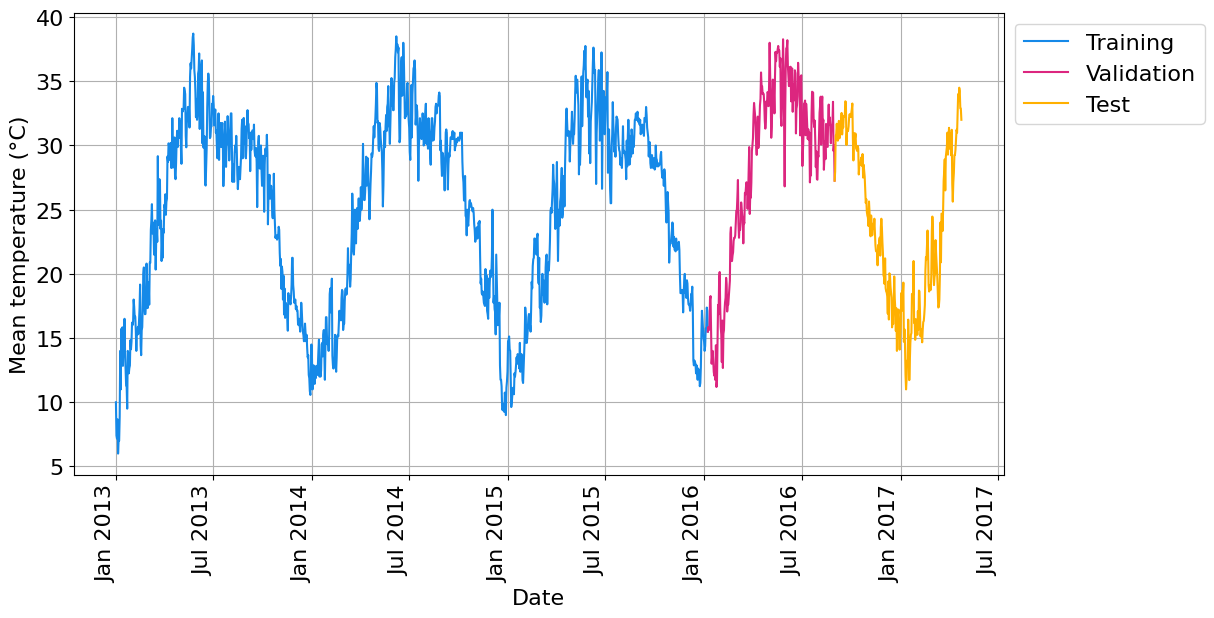

In [9]:
# Plot temperature variation across training dataset
fig = plt.figure(figsize=(12,6))
plt.plot(train_df["datetimes"], train_df["meantemp"], label="Training", c="#1589e8")
plt.plot(val_df["datetimes"], val_df["meantemp"], label="Validation", c="#dc267f")
plt.plot(test_df["datetimes"], test_df["meantemp"], label="Test", c="#ffb000")
ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=6))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
plt.xticks(rotation=90, ha="right")
ax.grid(visible=True)
plt.xlabel("Date")
plt.ylabel("Mean temperature (°C)")
plt.legend(bbox_to_anchor=(1.0, 1.0))

In [10]:
# Normalise inputs to be between 0 and 1
scaler = MinMaxScaler()

train_df["meantemp_norm"] = scaler.fit_transform(train_df[["meantemp"]])
val_df["meantemp_norm"] = scaler.fit_transform(val_df[["meantemp"]])
test_df["meantemp_norm"] = scaler.fit_transform(test_df[["meantemp"]])

# Convert to numpy array for sequence creation
meantemp_train = train_df["meantemp_norm"].values
meantemp_val = val_df["meantemp_norm"].values
meantemp_test = test_df["meantemp_norm"].values

In [11]:
# Create sequences
X_train, y_train = create_sequences(meantemp_train, SEQ_LENGTH, PRED_LENGTH)
X_val, y_val = create_sequences(meantemp_val, SEQ_LENGTH, PRED_LENGTH)
X_test, y_test = create_sequences(meantemp_test, SEQ_LENGTH, PRED_LENGTH)

# Convert arrays to PyTorch tensors
X_train = torch.Tensor(X_train).unsqueeze(-1) # Shape: (batch, seq, input_size)
y_train = torch.Tensor(y_train)
X_val = torch.Tensor(X_val).unsqueeze(-1) # Shape: (batch, seq, input_size)
y_val = torch.Tensor(y_val)
X_test = torch.Tensor(X_test).unsqueeze(-1)
y_test = torch.Tensor(y_test)

In [12]:
len_data = len(X_train) + len(X_val) + len(X_test)
print(f"Train:val:test ratio: {len(X_train)}:\
{len(X_val)}:{len(X_test)}")
print(f"Train:val:test ratio: \
{len(X_train)/len_data*100:.2f}%:\
{len(X_val)/len_data*100:.2f}%:\
{len(X_test)/len_data*100:.2f}%")

Train:val:test ratio: 1083:217:217
Train:val:test ratio: 71.39%:14.30%:14.30%


## Define and train models

* input_size = 1 because we have one feature (value per time step).
* hidden_size is the size of the hidden state.
* batch_first=True ensures input is in the format (batch, seq_len, input_size).

### Train models

In [13]:
from torch import nn
import torch.optim as optim

=== Starting training ===
Training Standard Model: RNN
Epoch [10/50], Loss: 0.0241
Epoch [20/50], Loss: 0.1465
Epoch [30/50], Loss: 0.1375
Epoch [40/50], Loss: 0.0252
Epoch [50/50], Loss: 0.0250


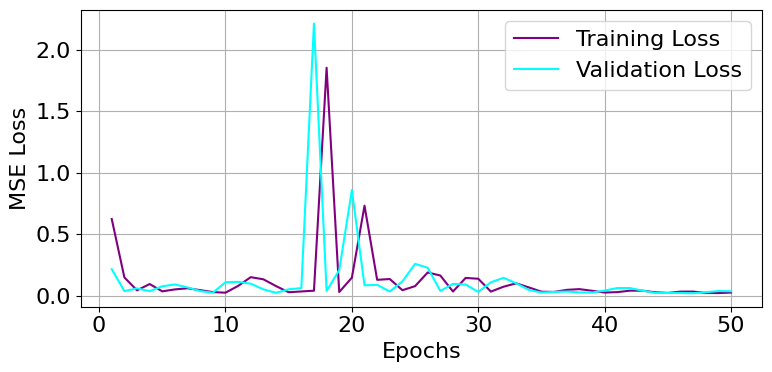

Training Standard Model: LSTM
Epoch [10/50], Loss: 0.1976
Epoch [20/50], Loss: 0.0664
Epoch [30/50], Loss: 0.0396
Epoch [40/50], Loss: 0.0302
Epoch [50/50], Loss: 0.0226


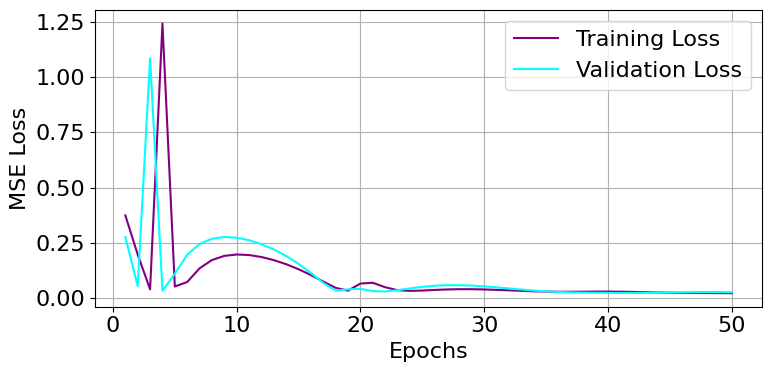

Training Standard Model: GRU
Epoch [10/50], Loss: 0.0337
Epoch [20/50], Loss: 0.0167
Epoch [30/50], Loss: 0.0050
Epoch [40/50], Loss: 0.0027
Epoch [50/50], Loss: 0.0027


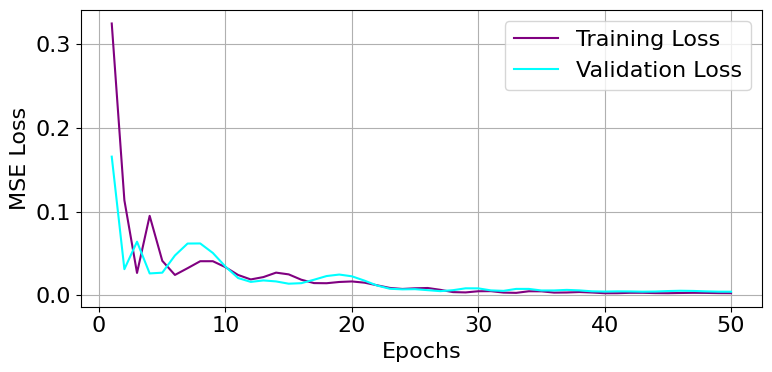

In [14]:
print("=== Starting training ===")
if PRED_LENGTH != 1:
    train_models(models, X_train, y_train, X_val, y_val, num_epochs=NUM_EPOCHS)
else:
    for name, model in models.items():
        print(f"Training Standard Model: {name}")
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.01)

        losses = []
        val_losses = []
        for epoch in range(NUM_EPOCHS):
            model.train()
            output = model(X_train)
            loss = criterion(output, y_train.reshape(-1,1))  # Compute loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss.item():.4f}")

            # Validation
            model.eval()
            val_preds = model(X_val)
            val_loss = criterion(val_preds, y_val.reshape(-1,1))
            val_losses.append(val_loss.item())

        plot_loss(losses, val_losses, NUM_EPOCHS)

## Evaluate
Check if predicted sequences align with true values


In [15]:
colours = {
    "Ground truth": "#1589e8",
    "LSTM": "#dc267f",
    "PI-LSTM": "#ffb000",
    "Starting data": "#631ff3",
    "RNN": "#fe5100",
    "GRU": "#ffb000"
}
    # "#631ff3", "#fe5100" # - IBM colourblind palette

In [16]:
y_preds = {}
y_preds_inv = {}  # Inverse normalisation back to true temperature
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze().numpy()
        y_preds[name] = preds # Predict on test set
        y_preds_inv[name] = np.array([scaler.inverse_transform(pred.reshape(-1, 1)) for pred in preds])

In [ ]:
if PRED_LENGTH ==1:
    for name in models.keys():
        # Calculate RMSE
        rmse = np.sqrt(np.mean((y_preds[name] - y_test.numpy().squeeze()) ** 2))

        # Calculate Pearson correlation
        correlation, _ = pearsonr(y_preds[name], y_test.squeeze())

        print(f"Metrics for model - {name}:")
        print(f"RMSE:\t\t{rmse}")
        print(f"P-CORR:\t\t{correlation}")

Metrics for model - RNN:
RMSE:		0.16301344335079193
P-CORR:		0.9667404890060425
Metrics for model - LSTM:
RMSE:		0.17633108794689178
P-CORR:		0.963572084903717
Metrics for model - GRU:
RMSE:		0.06852830201387405
P-CORR:		0.9679720997810364


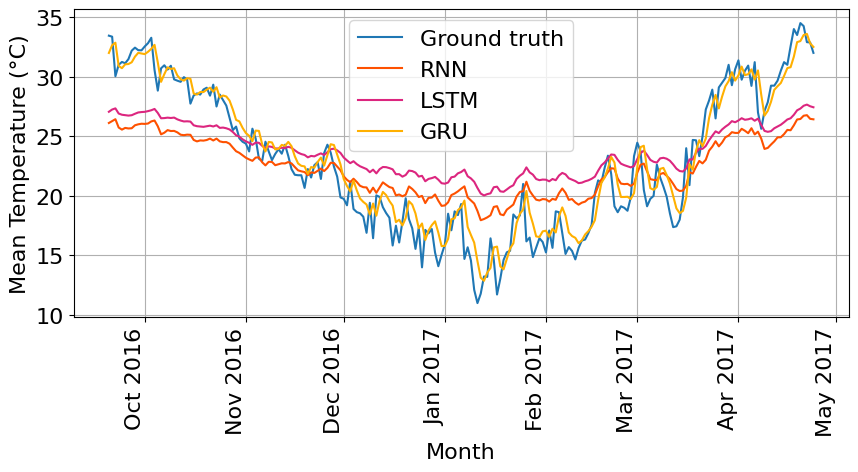

In [27]:
# Plot 5 random examples from test set!
if PRED_LENGTH > 1:
    for i in np.random.choice(range(len(y_test)-SEQ_LENGTH-1), 5):
        # Plot actual vs predicted 
        plt.figure(figsize=(10, 4))
        times = test_df["datetimes"].values[i+SEQ_LENGTH:i+SEQ_LENGTH+PRED_LENGTH]
        plt.plot(times, y_test[i], '--', label='Ground truth', c=colours['Ground truth'])
        for name in models.keys():
            plt.plot(times, y_preds[name][i], label=name, c=colours[name])
        ax = plt.gca()
        ax.grid(visible=True, axis="x")
        ax.xaxis.set_major_locator(DayLocator(interval=1))
        ax.xaxis.set_major_formatter(DateFormatter('%d %b %Y'))
        plt.xticks(rotation=90)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()
else:
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


    # Plot actual vs predicted 
    months = MonthLocator()
    plt.figure(figsize=(10, 4))
    plt.plot(test_df["datetimes"].values[SEQ_LENGTH:], y_test_inv, label='Ground truth')
    for name in models.keys():
        plt.plot(test_df["datetimes"].values[SEQ_LENGTH:], y_preds_inv[name].reshape(-1,1), label=name, c=colours[name])
    ax = plt.gca()
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
    plt.xticks(rotation=90, ha="right")
    plt.grid(visible=True)
    plt.xlabel("Month")
    plt.ylabel("Mean Temperature (°C)")
    plt.legend()
    plt.show()

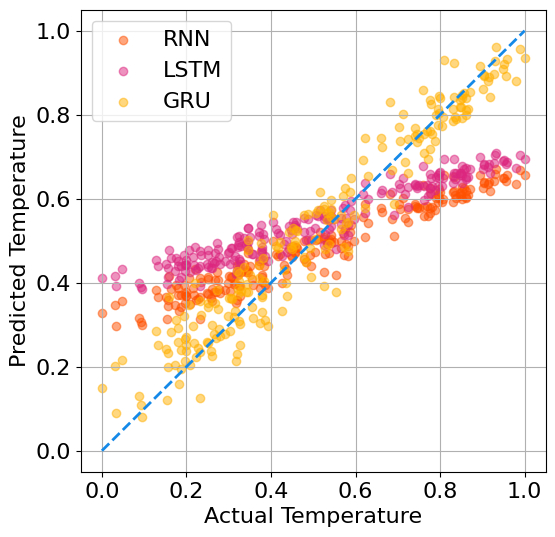

In [28]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    plt.scatter(y_test.reshape(-1,1), y_preds[name].reshape(-1,1), alpha=0.5, label=name, c=colours[name])
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '--', lw=2, c=colours['Ground truth'])
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()

## Autoregressive Forecasting

In [19]:
y_forecast = {}
start_data = X_test[0:1]  # Starting data: first sequence of X_test
desired_length = len(test_df)-SEQ_LENGTH
for name, model in models.items():
    print(f"Forcasting for model: {name}")
    forecast = forecast_with_model(model, start_data, desired_length, PRED_LENGTH)
    if PRED_LENGTH > 1:
        y_forecast[name] = scaler.inverse_transform(forecast)
    else:
        y_forecast[name] = scaler.inverse_transform(forecast.reshape(-1,1))

Forcasting for model: RNN
Forcasting for model: LSTM
Forcasting for model: GRU


In [20]:
true_temps = test_df["meantemp"].values[SEQ_LENGTH:]
forecast_dates = test_df["datetimes"].values[SEQ_LENGTH:]

In [21]:
for name in models.keys():
    # Calculate RMSE
    rmse = np.sqrt(np.mean((y_forecast[name].squeeze() - true_temps) ** 2))

    # Calculate Pearson correlation
    correlation, _ = pearsonr(y_forecast[name].squeeze(), true_temps)

    print(f"Metrics for model - {name}:")
    print(f"RMSE:\t\t{rmse}")
    print(f"P-CORR:\t\t{correlation}")

Metrics for model - RNN:
RMSE:		6.004948922404692
P-CORR:		0.221162589032121
Metrics for model - LSTM:
RMSE:		6.134599335050256
P-CORR:		0.26560003203152655
Metrics for model - GRU:
RMSE:		9.13149987566262
P-CORR:		0.5011509256124311


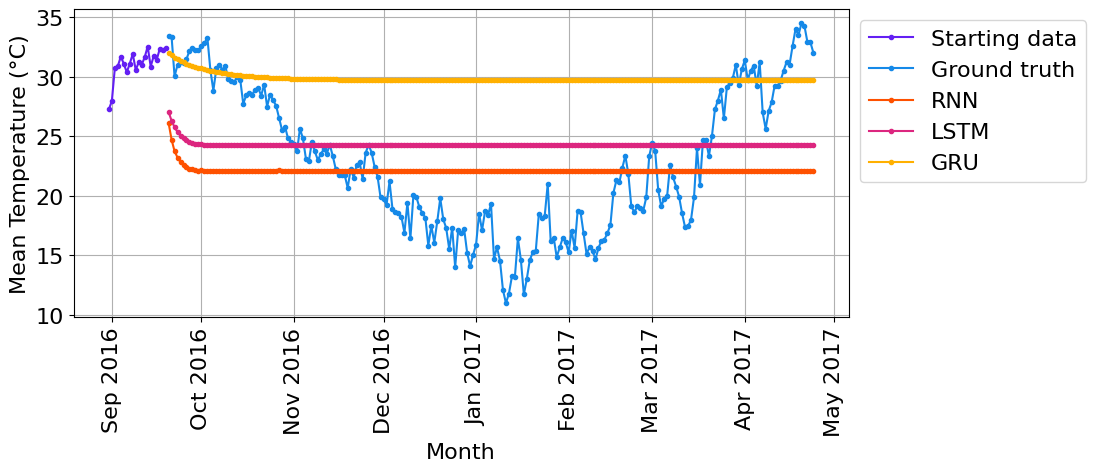

In [33]:
# Plot actual vs predicted
plt.figure(figsize=(10, 4))

# Starting data: first sequence of X_test
start_data_inv = scaler.inverse_transform(start_data.reshape(-1,1)).squeeze()
start_data_dates = test_df["datetimes"].values[:SEQ_LENGTH]
plt.plot(start_data_dates, start_data_inv, marker='.', label='Starting data', c=colours['Starting data'])

# Ground truth: test data across region predicted for
plt.plot(forecast_dates, true_temps, label='Ground truth', marker='.', c=colours['Ground truth'])

# Predictions
for name in models.keys():
    plt.plot(forecast_dates, y_forecast[name], label=name, marker='.', c=colours[name])
# plt.title("Autoregressive Forecasted Data")
ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=1))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

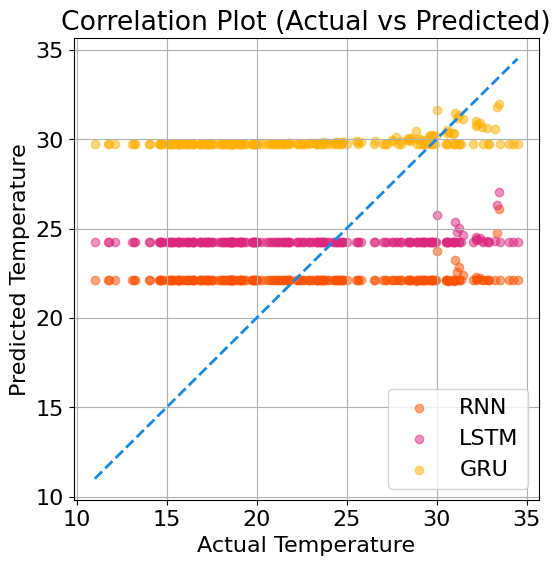

In [23]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    plt.scatter(true_temps, y_forecast[name], alpha=0.5, label=name, c=colours[name])
plt.plot([true_temps.min(), true_temps.max()], 
         [true_temps.min(), true_temps.max()], 
         '--', lw=2, c=colours['Ground truth'])
plt.title('Correlation Plot (Actual vs Predicted)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()
